# 09 - Final Model Evaluation and Finalization

## Objective

Evaluate the baseline and tuned models, select the final model for every stock and prediction horizon, and retrain the selected models on all available labeled data.

### Model selection rule

The final model is selected using **mean Time-Series Cross-Validation accuracy only**.

The final 20% chronological test set is retained as an independent evaluation set and is **not used for model selection**.

### Final output

**8 stocks × 3 horizons = 24 saved models**


## 1. Imports

The final-model implementation is handled by `src/final_model.py`.

This notebook is responsible for analysis, verification, feature-importance visualization, and reporting.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier


import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import STOCKS, FEATURES
from src.train_models import HORIZONS
from src.final_model import (
    select_best_models,
    load_best_params,
    train_final_models,
)


## 2. Project Configuration

In [4]:
stocks = STOCKS
horizons = HORIZONS
features = FEATURES

print("Stocks:", stocks)
print("Horizons:", horizons)
print("Features:", len(features))
print("Final models:", len(stocks) * len(horizons))


Stocks: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS']
Horizons: ['1D', '5D', '20D']
Features: 18
Final models: 24


## 3. Load ML-Ready Data

Load the prepared datasets for feature-importance analysis.

Final model training itself is handled by `src/final_model.py`.


In [5]:
ml_data = {}

for horizon in horizons:
    ml_data[horizon] = {}

    for stock in stocks:
        df = pd.read_csv(
            f"../data/ml_ready/{stock}_{horizon}_ml.csv",
            parse_dates=["Date"],
        )

        df = (
            df.sort_values("Date")
            .reset_index(drop=True)
        )

        ml_data[horizon][stock] = df

print("Loaded all ML-ready datasets.")


Loaded all ML-ready datasets.


## 4. Feature and Target Selection

In [6]:
X = {}
y = {}

for horizon in horizons:

    X[horizon] = {}
    y[horizon] = {}

    target_column = f"Target_{horizon}"

    for stock in stocks:

        X[horizon][stock] = (
            ml_data[horizon][stock][features]
        )

        y[horizon][stock] = (
            ml_data[horizon][stock][target_column]
            .astype(int)
        )

print("Feature and target dictionaries created.")


Feature and target dictionaries created.


## 5. Chronological Train-Test Split

The final 20% of observations is kept as the independent test set for analysis.

Time-Series CV used for model selection is already performed inside the reusable training modules on the training portion.


In [7]:
X_train = {}
X_test = {}

y_train = {}
y_test = {}

for horizon in horizons:

    X_train[horizon] = {}
    X_test[horizon] = {}

    y_train[horizon] = {}
    y_test[horizon] = {}

    for stock in stocks:

        X_stock = X[horizon][stock]
        y_stock = y[horizon][stock]

        split_idx = int(len(X_stock) * 0.80)

        X_train[horizon][stock] = (
            X_stock.iloc[:split_idx].copy()
        )

        X_test[horizon][stock] = (
            X_stock.iloc[split_idx:].copy()
        )

        y_train[horizon][stock] = (
            y_stock.iloc[:split_idx].copy()
        )

        y_test[horizon][stock] = (
            y_stock.iloc[split_idx:].copy()
        )

print("Chronological 80/20 splits created.")


Chronological 80/20 splits created.


## 6. Random Forest Feature Importance

Feature importance is calculated from a baseline Random Forest trained on the chronological training portion.

This analysis is descriptive and is separate from final model selection.


In [8]:
feature_importance = {}

for horizon in horizons:

    feature_importance[horizon] = {}

    for stock in stocks:

        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
        )

        model.fit(
            X_train[horizon][stock],
            y_train[horizon][stock],
        )

        importance_df = (
            pd.DataFrame(
                {
                    "Feature": features,
                    "Importance": model.feature_importances_,
                }
            )
            .sort_values(
                "Importance",
                ascending=False,
            )
            .reset_index(drop=True)
        )

        feature_importance[horizon][stock] = (
            importance_df
        )

print("Feature importance calculated.")


Feature importance calculated.


## 7. Feature Importance by Stock

In [9]:
for horizon in horizons:

    print(f"\n========== {horizon} ==========")

    for stock in stocks:

        print(f"\n{stock}")

        display(
            feature_importance[horizon][stock].head(10)
        )



========== 1D ==========

AAPL


,Feature,Importance
0,Return_Lag_3,0.065365
1,Return_Lag_2,0.064080
2,Open_Close_Change,0.063889
3,Return_Lag_1,0.063808
4,Volume_Change,0.063588
5,Volatility_20,0.061528
6,High_Low_Range,0.059855
7,RSI_14,0.058594
8,Daily_Return,0.056659
9,MACD,0.055657



MSFT


,Feature,Importance
0,Volume_Change,0.070651
1,Return_Lag_3,0.066093
2,Return_Lag_2,0.064023
3,Open_Close_Change,0.062844
4,RSI_14,0.062812
5,Return_Lag_1,0.061405
6,Volatility_20,0.061086
7,MACD_Signal,0.059213
8,High_Low_Range,0.058913
9,MACD_Hist,0.058831



NVDA


...

,Feature,Importance
0,SMA_50,0.102386
1,EMA_20,0.089708
2,Adj Close,0.089210
3,SMA_20,0.088281
4,MACD,0.084304
5,Volatility_20,0.082623
6,SMA_5,0.081185
7,MACD_Signal,0.079272
8,MACD_Hist,0.054623
9,RSI_14,0.049957



HDFCBANK.NS


,Feature,Importance
0,SMA_50,0.116390
1,SMA_5,0.106851
2,SMA_20,0.104303
3,EMA_20,0.098788
4,Adj Close,0.095213
5,Volatility_20,0.085412
6,MACD_Signal,0.054303
7,MACD_Hist,0.053066
8,MACD,0.053054
9,RSI_14,0.053004



INFY.NS


,Feature,Importance
0,SMA_50,0.118118
1,SMA_20,0.098744
2,EMA_20,0.092378
3,Adj Close,0.092226
4,SMA_5,0.085920
5,Volatility_20,0.082092
6,MACD_Signal,0.068467
7,MACD,0.061742
8,MACD_Hist,0.060051
9,RSI_14,0.047257


## 8. Overall Feature Importance by Horizon

Calculate the average feature importance across all stocks for each prediction horizon.


In [10]:
overall_importance = {}

for horizon in horizons:

    importance_df = pd.DataFrame(
        {
            stock: (
                feature_importance[horizon][stock]
                .set_index("Feature")["Importance"]
            )
            for stock in stocks
        }
    )

    importance_df["Average Importance"] = (
        importance_df.mean(axis=1)
    )

    importance_df = (
        importance_df[["Average Importance"]]
        .sort_values(
            "Average Importance",
            ascending=False,
        )
    )

    overall_importance[horizon] = importance_df

    display(importance_df)


,Average Importance
Feature,
Volume_Change,0.065482
Return_Lag_3,0.064871
Return_Lag_2,0.064851
Return_Lag_1,0.064803
Volatility_20,0.062616
RSI_14,0.061313
Open_Close_Change,0.060678
MACD_Hist,0.058517
High_Low_Range,0.058198


,Average Importance
Feature,
Volatility_20,0.072317
SMA_50,0.066163
MACD_Signal,0.065080
SMA_20,0.063166
MACD_Hist,0.062643
MACD,0.062436
EMA_20,0.062310
SMA_5,0.059417
Adj Close,0.059286


,Average Importance
Feature,
SMA_50,0.105590
SMA_20,0.089894
Adj Close,0.088733
EMA_20,0.088629
Volatility_20,0.086865
SMA_5,0.083053
MACD_Signal,0.074328
MACD,0.067416
MACD_Hist,0.062993


## 9. Overall Feature Importance Plots

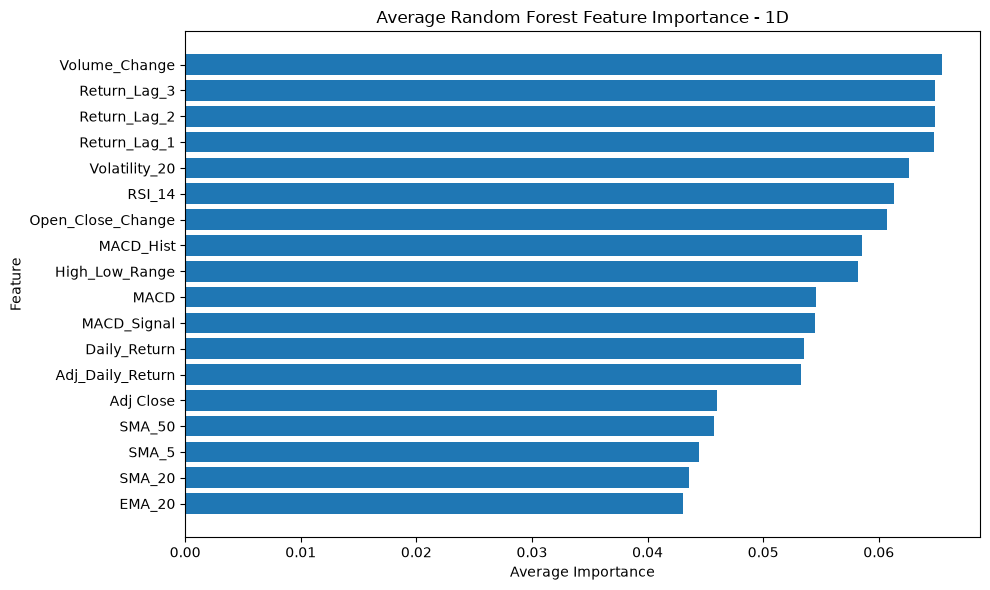

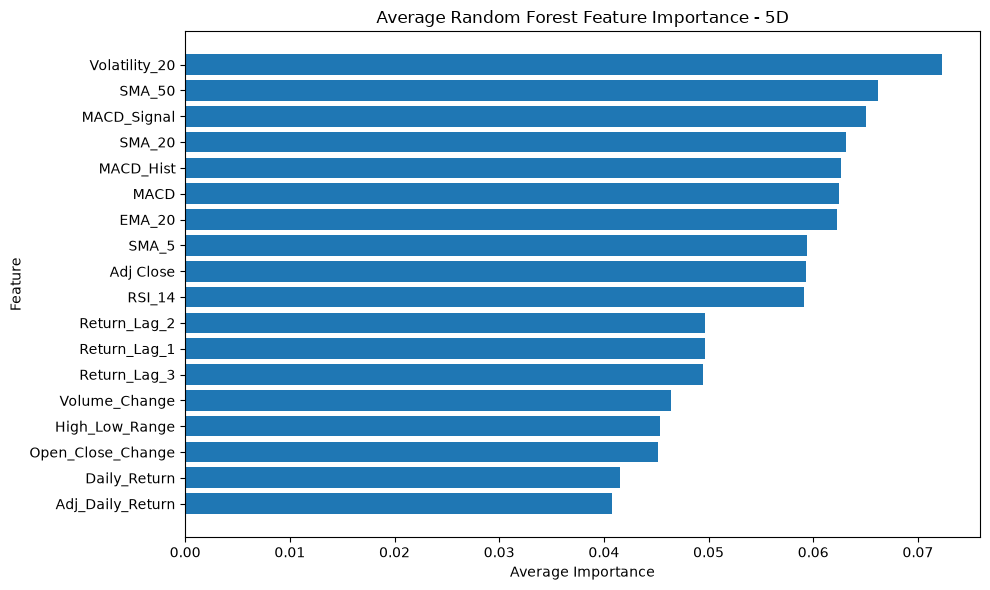

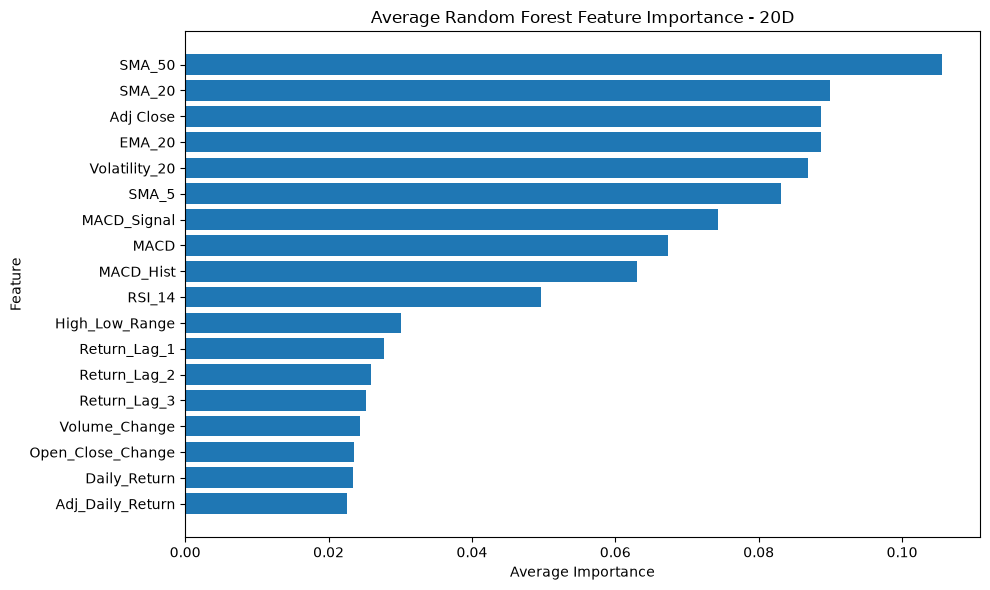

In [11]:
for horizon in horizons:

    importance_df = overall_importance[horizon]

    plt.figure(figsize=(10, 6))

    plt.barh(
        importance_df.index,
        importance_df["Average Importance"],
    )

    plt.gca().invert_yaxis()

    plt.title(
        f"Average Random Forest Feature Importance - {horizon}"
    )
    plt.xlabel("Average Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


## 10. Load Model-Selection Results

The reusable final-model module combines:

- Logistic Regression test results
- Default Random Forest test results
- Tuned Random Forest test results
- Logistic Regression Time-Series CV
- Default Random Forest Time-Series CV
- Tuned Random Forest Time-Series CV


In [12]:
comparison_df = select_best_models()

display(comparison_df)


,Horizon,Stock,Logistic Test Accuracy,Logistic Test Precision,Logistic Test Recall,Logistic Test F1,Default RF Test Accuracy,Default RF Test Precision,Default RF Test Recall,Default RF Test F1,Tuned RF Test Accuracy,Tuned RF Test Precision,Tuned RF Test Recall,Tuned RF Test F1,Logistic CV,Default RF CV,Tuned RF CV,Best Model,Best CV Accuracy
0,1D,AAPL,0.487047,0.540351,0.481250,0.509091,0.457686,0.687500,0.034375,0.065476,0.452504,1.000000,0.009375,0.018576,0.487047,0.473575,0.503742,Tuned Random Forest,0.503742
1,1D,AMZN,0.509499,0.541176,0.308725,0.393162,0.519862,0.592593,0.214765,0.315271,0.485320,0.500000,0.023490,0.044872,0.520725,0.483420,0.491652,Logistic Regression,0.520725
2,1D,HDFCBANK.NS,0.467487,0.469854,0.824818,0.598675,0.490334,0.414894,0.142336,0.211957,0.502636,0.452632,0.156934,0.233062,0.499471,0.504233,0.512324,Tuned Random Forest,0.512324
3,1D,INFY.NS,0.520211,0.503448,0.530909,0.516814,0.511424,0.493088,0.389091,0.434959,0.483304,0.464419,0.450909,0.457565,0.501058,0.483069,0.484155,Logistic Regression,0.501058
4,1D,MSFT,0.487047,0.510000,0.668852,0.578723,0.488774,0.520548,0.373770,0.435115,0.468048,0.493724,0.386885,0.433824,0.516580,0.489119,0.492228,Logistic Regression,0.516580
5,1D,NVDA,0.523316,0.525735,0.940789,0.674528,0.531952,0.539568,0.740132,0.624133,0.530225,0.536364,0.776316,0.634409,0.502073,0.482902,0.485320,Logistic Regression,0.502073
6,1D,RELIANCE.NS,0.476274,0.481395,0.734043,0.581461,0.560633,0.572072,0.450355,0.503968,0.546573,0.546875,0.496454,0.520446,0.498942,0.512698,0.527582,Tuned Random Forest,0.527582
7,1D,TCS.NS,0.481547,0.438650,0.560784,0.492255,0.488576,0.439597,0.513725,0.473779,0.478032,0.436364,0.564706,0.492308,0.511640,0.510053,0.504695,Logistic Regression,0.511640
8,20D,AAPL,0.534722,0.665552,0.542234,0.597598,0.413194,0.754386,0.117166,0.202830,0.392361,0.814815,0.059946,0.111675,0.525326,0.404178,0.418551,Logistic Regression,0.525326
9,20D,AMZN,0.532986,0.671875,0.385075,0.489564,0.548611,0.570621,0.904478,0.699769,0.550347,0.569091,0.934328,0.707345,0.539426,0.509138,0.518841,Logistic Regression,0.539426


## 11. Verify Model-Selection Columns

In [13]:
print("Comparison columns:")
print(comparison_df.columns.tolist())

print("\nRows:", len(comparison_df))
print("Expected rows:", len(stocks) * len(horizons))


Comparison columns:
['Horizon', 'Stock', 'Logistic Test Accuracy', 'Logistic Test Precision', 'Logistic Test Recall', 'Logistic Test F1', 'Default RF Test Accuracy', 'Default RF Test Precision', 'Default RF Test Recall', 'Default RF Test F1', 'Tuned RF Test Accuracy', 'Tuned RF Test Precision', 'Tuned RF Test Recall', 'Tuned RF Test F1', 'Logistic CV', 'Default RF CV', 'Tuned RF CV', 'Best Model', 'Best CV Accuracy']

Rows: 24
Expected rows: 24


## 12. Final Model Selection

The model with the highest **mean Time-Series CV accuracy** is selected independently for every stock and prediction horizon.

The test-set accuracy is not used to select the model.


In [14]:
cv_model_columns = [
    "Logistic CV",
    "Default RF CV",
    "Tuned RF CV",
]

comparison_df[
    [
        "Horizon",
        "Stock",
        *cv_model_columns,
        "Best Model",
        "Best CV Accuracy",
    ]
]


,Horizon,Stock,Logistic CV,Default RF CV,Tuned RF CV,Best Model,Best CV Accuracy
0,1D,AAPL,0.487047,0.473575,0.503742,Tuned Random Forest,0.503742
1,1D,AMZN,0.520725,0.483420,0.491652,Logistic Regression,0.520725
2,1D,HDFCBANK.NS,0.499471,0.504233,0.512324,Tuned Random Forest,0.512324
3,1D,INFY.NS,0.501058,0.483069,0.484155,Logistic Regression,0.501058
4,1D,MSFT,0.516580,0.489119,0.492228,Logistic Regression,0.516580
5,1D,NVDA,0.502073,0.482902,0.485320,Logistic Regression,0.502073
6,1D,RELIANCE.NS,0.498942,0.512698,0.527582,Tuned Random Forest,0.527582
7,1D,TCS.NS,0.511640,0.510053,0.504695,Logistic Regression,0.511640
8,20D,AAPL,0.525326,0.404178,0.418551,Logistic Regression,0.525326
9,20D,AMZN,0.539426,0.509138,0.518841,Logistic Regression,0.539426


## 13. Final Model Choice

In [15]:
final_model_choice = {
    horizon: {}
    for horizon in horizons
}

for horizon in horizons:

    for stock in stocks:

        row = comparison_df[
            (comparison_df["Horizon"] == horizon)
            & (comparison_df["Stock"] == stock)
        ]

        final_model_choice[horizon][stock] = (
            row["Best Model"].iloc[0]
        )

final_model_choice


{'1D': {'AAPL': 'Tuned Random Forest',
  'MSFT': 'Logistic Regression',
  'NVDA': 'Logistic Regression',
  'AMZN': 'Logistic Regression',
  'RELIANCE.NS': 'Tuned Random Forest',
  'TCS.NS': 'Logistic Regression',
  'HDFCBANK.NS': 'Tuned Random Forest',
  'INFY.NS': 'Logistic Regression'},
 '5D': {'AAPL': 'Logistic Regression',
  'MSFT': 'Logistic Regression',
  'NVDA': 'Logistic Regression',
  'AMZN': 'Logistic Regression',
  'RELIANCE.NS': 'Tuned Random Forest',
  'TCS.NS': 'Logistic Regression',
  'HDFCBANK.NS': 'Logistic Regression',
  'INFY.NS': 'Logistic Regression'},
 '20D': {'AAPL': 'Logistic Regression',
  'MSFT': 'Tuned Random Forest',
  'NVDA': 'Logistic Regression',
  'AMZN': 'Logistic Regression',
  'RELIANCE.NS': 'Tuned Random Forest',
  'TCS.NS': 'Default Random Forest',
  'HDFCBANK.NS': 'Tuned Random Forest',
  'INFY.NS': 'Logistic Regression'}}

## 14. Best Tuned Parameters

The Optuna parameters are loaded only when a stock-horizon combination selects the Tuned Random Forest.


In [16]:
best_params = load_best_params()

best_params_df = pd.DataFrame(
    [
        {
            "Horizon": horizon,
            "Stock": stock,
            **best_params[horizon][stock],
        }
        for horizon in horizons
        for stock in stocks
    ]
)

display(best_params_df)


,Horizon,Stock,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features
0,1D,AAPL,91,5,6,5,sqrt
1,1D,MSFT,146,15,2,5,sqrt
2,1D,NVDA,91,10,7,2,log2
3,1D,AMZN,190,5,2,5,sqrt
4,1D,RELIANCE.NS,172,10,5,5,log2
5,1D,TCS.NS,199,10,4,2,sqrt
6,1D,HDFCBANK.NS,126,14,2,3,sqrt
7,1D,INFY.NS,165,5,8,5,log2
8,5D,AAPL,68,8,5,3,log2
9,5D,MSFT,178,12,5,2,log2


## 15. Train and Save Final Models

The selected model for every stock and horizon is retrained using **all available labeled data**.

The reusable function also saves:

`models/final/{stock}_{horizon}_model.joblib`

This creates 24 final deployment-ready model files.


In [17]:
final_results = train_final_models()

final_model_choice = (
    final_results["final_model_choice"]
)

final_models = (
    final_results["final_models"]
)

comparison_df = (
    final_results["comparison_df"]
)

print("Final model training completed.")


✓ AAPL            1D   → Tuned Random Forest
✓ MSFT            1D   → Logistic Regression
✓ NVDA            1D   → Logistic Regression
✓ AMZN            1D   → Logistic Regression
✓ RELIANCE.NS     1D   → Tuned Random Forest
✓ TCS.NS          1D   → Logistic Regression
✓ HDFCBANK.NS     1D   → Tuned Random Forest
✓ INFY.NS         1D   → Logistic Regression
✓ AAPL            5D   → Logistic Regression
✓ MSFT            5D   → Logistic Regression
✓ NVDA            5D   → Logistic Regression
✓ AMZN            5D   → Logistic Regression
✓ RELIANCE.NS     5D   → Tuned Random Forest
✓ TCS.NS          5D   → Logistic Regression
✓ HDFCBANK.NS     5D   → Logistic Regression
✓ INFY.NS         5D   → Logistic Regression
✓ AAPL            20D  → Logistic Regression
✓ MSFT            20D  → Tuned Random Forest
✓ NVDA            20D  → Logistic Regression
✓ AMZN            20D  → Logistic Regression
✓ RELIANCE.NS     20D  → Tuned Random Forest
✓ TCS.NS          20D  → Default Random Forest
✓ HDFCBA

## 16. Verify Final Model Files

In [18]:
from src.config import FINAL_MODELS_DIR

model_files = sorted(
    FINAL_MODELS_DIR.glob("*_model.joblib")
)

print("Final model files:", len(model_files))
print("Expected:", len(stocks) * len(horizons))

for path in model_files:
    print(path.name)


Final model files: 24
Expected: 24
AAPL_1D_model.joblib
AAPL_20D_model.joblib
AAPL_5D_model.joblib
AMZN_1D_model.joblib
AMZN_20D_model.joblib
AMZN_5D_model.joblib
HDFCBANK.NS_1D_model.joblib
HDFCBANK.NS_20D_model.joblib
HDFCBANK.NS_5D_model.joblib
INFY.NS_1D_model.joblib
INFY.NS_20D_model.joblib
INFY.NS_5D_model.joblib
MSFT_1D_model.joblib
MSFT_20D_model.joblib
MSFT_5D_model.joblib
NVDA_1D_model.joblib
NVDA_20D_model.joblib
NVDA_5D_model.joblib
RELIANCE.NS_1D_model.joblib
RELIANCE.NS_20D_model.joblib
RELIANCE.NS_5D_model.joblib
TCS.NS_1D_model.joblib
TCS.NS_20D_model.joblib
TCS.NS_5D_model.joblib


## 17. Final Model Distribution

In [19]:
selection_summary = (
    comparison_df["Best Model"]
    .value_counts()
    .rename_axis("Model")
    .reset_index(name="Count")
)

selection_summary


,Model,Count
0,Logistic Regression,16
1,Tuned Random Forest,7
2,Default Random Forest,1


## 18. Save / Verify Final Selection Artifacts

The final-model pipeline saves:

- `results/final_model_selection.csv`
- `results/final_model_choice.json`
- `models/final/*_model.joblib`


In [20]:
display(comparison_df)

print(
    "\nFinal model-selection artifacts have been saved "
    "by src.final_model."
)


,Horizon,Stock,Logistic Test Accuracy,Logistic Test Precision,Logistic Test Recall,Logistic Test F1,Default RF Test Accuracy,Default RF Test Precision,Default RF Test Recall,Default RF Test F1,Tuned RF Test Accuracy,Tuned RF Test Precision,Tuned RF Test Recall,Tuned RF Test F1,Logistic CV,Default RF CV,Tuned RF CV,Best Model,Best CV Accuracy
0,1D,AAPL,0.487047,0.540351,0.481250,0.509091,0.457686,0.687500,0.034375,0.065476,0.452504,1.000000,0.009375,0.018576,0.487047,0.473575,0.503742,Tuned Random Forest,0.503742
1,1D,AMZN,0.509499,0.541176,0.308725,0.393162,0.519862,0.592593,0.214765,0.315271,0.485320,0.500000,0.023490,0.044872,0.520725,0.483420,0.491652,Logistic Regression,0.520725
2,1D,HDFCBANK.NS,0.467487,0.469854,0.824818,0.598675,0.490334,0.414894,0.142336,0.211957,0.502636,0.452632,0.156934,0.233062,0.499471,0.504233,0.512324,Tuned Random Forest,0.512324
3,1D,INFY.NS,0.520211,0.503448,0.530909,0.516814,0.511424,0.493088,0.389091,0.434959,0.483304,0.464419,0.450909,0.457565,0.501058,0.483069,0.484155,Logistic Regression,0.501058
4,1D,MSFT,0.487047,0.510000,0.668852,0.578723,0.488774,0.520548,0.373770,0.435115,0.468048,0.493724,0.386885,0.433824,0.516580,0.489119,0.492228,Logistic Regression,0.516580
5,1D,NVDA,0.523316,0.525735,0.940789,0.674528,0.531952,0.539568,0.740132,0.624133,0.530225,0.536364,0.776316,0.634409,0.502073,0.482902,0.485320,Logistic Regression,0.502073
6,1D,RELIANCE.NS,0.476274,0.481395,0.734043,0.581461,0.560633,0.572072,0.450355,0.503968,0.546573,0.546875,0.496454,0.520446,0.498942,0.512698,0.527582,Tuned Random Forest,0.527582
7,1D,TCS.NS,0.481547,0.438650,0.560784,0.492255,0.488576,0.439597,0.513725,0.473779,0.478032,0.436364,0.564706,0.492308,0.511640,0.510053,0.504695,Logistic Regression,0.511640
8,20D,AAPL,0.534722,0.665552,0.542234,0.597598,0.413194,0.754386,0.117166,0.202830,0.392361,0.814815,0.059946,0.111675,0.525326,0.404178,0.418551,Logistic Regression,0.525326
9,20D,AMZN,0.532986,0.671875,0.385075,0.489564,0.548611,0.570621,0.904478,0.699769,0.550347,0.569091,0.934328,0.707345,0.539426,0.509138,0.518841,Logistic Regression,0.539426



Final model-selection artifacts have been saved by src.final_model.


## Conclusion

StockVision now has a complete final-model pipeline:

1. Baseline models were evaluated in Notebook 07.
2. Random Forest hyperparameters were optimized in Notebook 08.
3. Model selection is based on mean Time-Series CV accuracy.
4. The final test set remains independent of model selection.
5. The selected model is retrained on all labeled data.
6. 24 final models are saved for the prediction pipeline.

The saved models can now be consumed by `src/prediction.py` and the Streamlit dashboard.
